# Goal: Create Fig. 1 plots

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse

import session_info
session_info.show()

/rfs/project/rfs-iCNyzSAaucw/lk530/miniconda3/envs/Scanpy/lib/python3.12/site-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/rfs/project/rfs-iCNyzSAaucw/lk530/miniconda3/envs/Scanpy/lib/python3.12/site-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/rfs/project/rfs-iCNyzSAaucw/lk530/miniconda3/envs/Scanpy/lib/python3.12/site-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/rfs/project/rfs-iCNyzSAaucw/lk530/miniconda3/envs/Scanpy/lib/python3.12/site-packages/session_info/main.py:213: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')`

In [2]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['savefig.transparent'] = True
matplotlib.rcParams['savefig.dpi'] = 300
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['pdf.fonttype'] = 42

save_dir='/rds/project/rds-C9woKbOCf2Y/lk530/T_cell_infection_atlas/Summary_plots/'

# Load the integrated T cell object

In [3]:
adata=sc.read_h5ad('/rfs/project/rfs-iCNyzSAaucw/lmd76/pan_infection/datasets/pan_infection_atlas/snakemake_toolbox/out/checkpoint_objects/checkpoint_6/adata.h5ad')
adata

AnnData object with n_obs × n_vars = 3859644 × 11025
    obs: 'Compartment_prediction', 'Cross_tissue_broad', 'Cross_tissue_detailed', 'IR_VDJ_1_j_call', 'IR_VDJ_1_junction_aa', 'IR_VDJ_1_v_call', 'IR_VJ_1_j_call', 'IR_VJ_1_junction_aa', 'IR_VJ_1_v_call', 'Lindeboom_broad', 'Lindeboom_detailed', 'age', 'alternative_qc_status', 'author_annotation', 'barcode', 'batch_condition', 'cell_passed_qc', 'cell_type', 'dataset', 'dataset_id', 'disease', 'doi', 'donor', 'donor_id', 'doubletdetection_prediction', 'doubletdetection_score', 'filtered', 'group', 'infection_stage', 'infection_status', 'log1p_n_counts', 'log1p_n_genes', 'modalities', 'n_counts', 'n_counts_hb', 'n_counts_mito', 'n_counts_ribo', 'n_genes', 'obs_names_before_t_cells', 'organ', 'original_annotation', 'passed_qc', 'pathogen', 'percent_hb', 'percent_mito', 'percent_ribo', 'percent_top50', 'qc_status', 'reannotation', 'reannotation_index', 'sample', 'sample_id', 'scrublet_prediction', 'scrublet_score', 'sex', 'study', 'tissue'

In [4]:
# remove B cells
adata = adata[adata.obs['annotation_level_3'] != 'B']
adata.obs['annotation_level_3'] = adata.obs['annotation_level_3'].cat.remove_unused_categories()

/tmp/ipykernel_170894/3702848115.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['annotation_level_3'] = adata.obs['annotation_level_3'].cat.remove_unused_categories()


- update the obs layers:

In [5]:
# Add the detailed infection metadata
infection_meta_df = pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/T_cell_infection_atlas/T_cell_atlas_infection_metadata_detailed.csv', index_col=0)

adata.obs.loc[infection_meta_df.index, 'severity_stage_detailed'] = infection_meta_df['severity_stage_detailed'].values

/tmp/ipykernel_170894/3467392967.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  infection_meta_df = pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/T_cell_infection_atlas/T_cell_atlas_infection_metadata_detailed.csv', index_col=0)


In [6]:
# Add the detailed study metadata
study_meta_df = pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/T_cell_infection_atlas/T_cell_atlas_study_metadata.csv', index_col=0)

adata.obs.loc[study_meta_df.index, 'author_year'] = study_meta_df['author_year'].values

/tmp/ipykernel_170894/3438548668.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  study_meta_df = pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/T_cell_infection_atlas/T_cell_atlas_study_metadata.csv', index_col=0)


In [7]:
# Load the updated T cell annotations
annotation_df = pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/T_cell_infection_atlas/T_cell_atlas_annotation_final.csv', index_col=0)


annot_cols=['annotation_level_1','annotation_level_2','annotation_level_3','annotation_level_4']
for annotation in annot_cols:
    adata.obs[annotation]=adata.obs[annotation].astype(str)
    adata.obs.loc[annotation_df.index, annotation] = annotation_df[annotation].values

/tmp/ipykernel_170894/1444133701.py:2: DtypeWarning: Columns (2,3,4) have mixed types. Specify dtype option on import or set low_memory=False.
  annotation_df = pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/T_cell_infection_atlas/T_cell_atlas_annotation_final.csv', index_col=0)


In [8]:
T_unconv = pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/JHub/LK07_T_cell_infection_atlas/T_unconv_reannotation.csv', index_col='barcode')

In [9]:
# Columns to consider for equality
annot_columns = ["annotation_level_4", "annotation_level_3", 
                 "annotation_level_2", "annotation_level_1"]

# Keep first occurrence only if duplicates have identical annotation entries
T_unconv_clean = T_unconv[~T_unconv.index.duplicated(keep=False)].copy()  # non-duplicates
duplicates = T_unconv[T_unconv.index.duplicated(keep=False)].copy()       # duplicated barcodes

# For duplicates, keep first only if all annotations are identical
duplicates_keep = duplicates.groupby(duplicates.index).filter(
    lambda x: (x[annot_columns].nunique() == 1).all()
).drop_duplicates(subset=annot_columns, keep='first')

# Combine cleaned duplicates with non-duplicates
T_unconv_final = pd.concat([T_unconv_clean, duplicates_keep])
T_unconv_final = T_unconv_final.sort_index()

print(f"Original entries: {T_unconv.shape[0]}")
print(f"After cleaning duplicates with identical annotations: {T_unconv_final.shape[0]}")

Original entries: 296738
After cleaning duplicates with identical annotations: 296727


In [10]:
annot_columns = ["annotation_level_4", "annotation_level_3", 
                  "annotation_level_2", "annotation_level_1"]

for col in annot_columns:
    adata.obs[col] = adata.obs["barcode"].map(T_unconv_final[col]).fillna(adata.obs[col])

In [11]:
# Add the pathogen metadata
pathogen_meta_df = pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/T_cell_infection_atlas/T_cell_atlas_pathogen_metadata.csv', index_col=0)

adata.obs['pathogen']=adata.obs['pathogen'].astype(str)
adata.obs.loc[pathogen_meta_df.index, 'pathogen'] = pathogen_meta_df['pathogen'].values

/tmp/ipykernel_170894/3321441195.py:2: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  pathogen_meta_df = pd.read_csv('/rds/project/rds-C9woKbOCf2Y/lk530/T_cell_infection_atlas/T_cell_atlas_pathogen_metadata.csv', index_col=0)


- Fig. 1c

In [19]:
adata.obs.loc[
    adata.obs['annotation_level_3'] == 'B',
    'annotation_level_1'
] = 'T CD4'

adata.obs['annotation_level_1'] = (
    adata.obs['annotation_level_1']
    .cat.remove_unused_categories()
)

In [13]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 10)

In [14]:
UMAP = np.load('/rfs/project/rfs-iCNyzSAaucw/lmd76/pan_infection/datasets/pan_infection_atlas/snakemake_toolbox/out/checkpoint_objects/checkpoint_6/UMAPs/all_T_cells_umap_neighbors_30_mindist_13_spread_1.npy')
adata.obsm["X_umap"] = UMAP

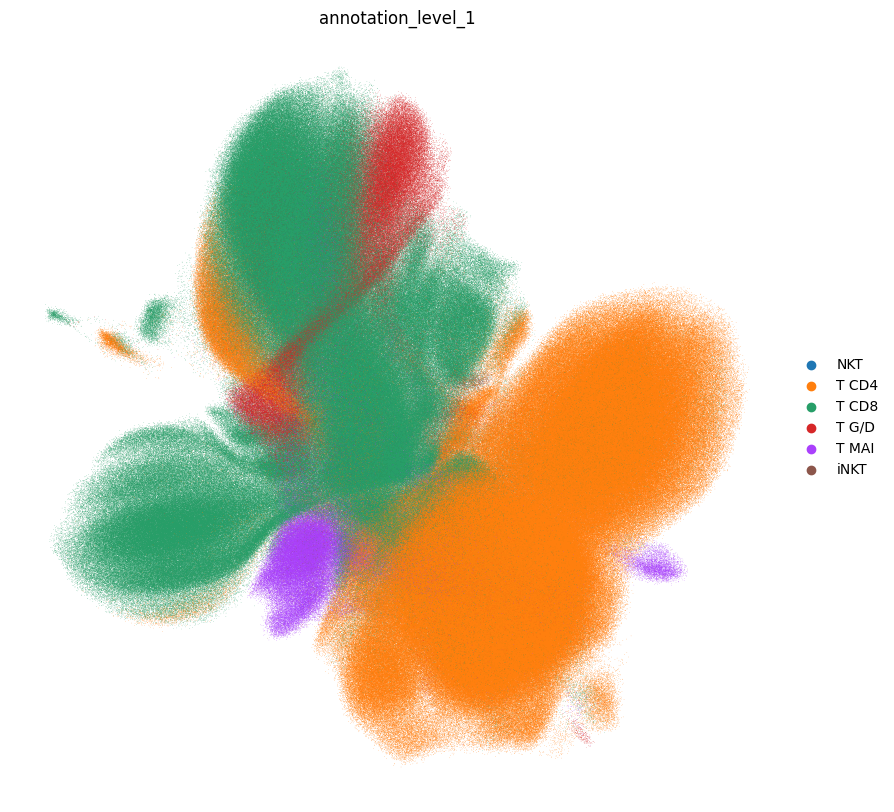

In [20]:
sc.pl.umap(adata, color='annotation_level_1', size=0.5, frameon=False, show=True)

#plt.savefig(save_dir+'Umap_level_1.pdf')

- Fig. 1d

/tmp/ipykernel_170894/693890406.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_df = df.groupby(['annotation_level_1', 'author_year']).size().reset_index(name='cell_count')


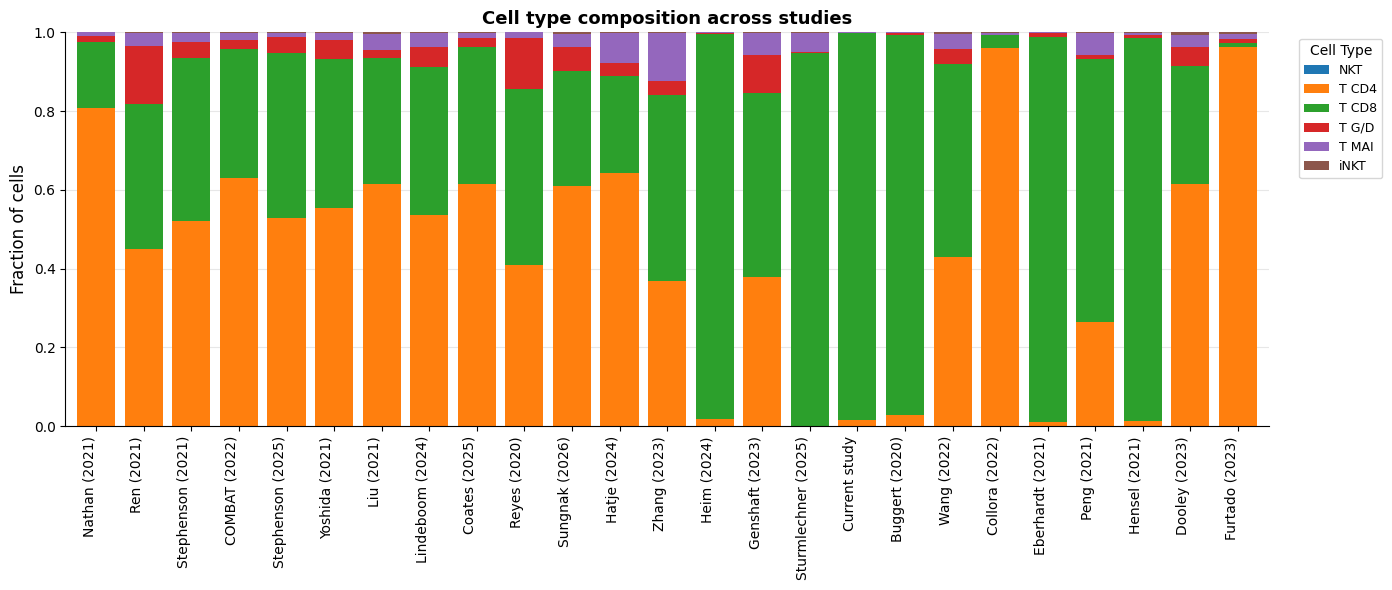

In [21]:
import matplotlib.pyplot as plt

# Define author order
author_order = [
    'Nathan (2021)',
    'Ren (2021)',
    'Stephenson (2021)',
    'COMBAT (2022)',
    'Stephenson (2025)',
    'Yoshida (2021)',
    'Liu (2021)',
    'Lindeboom (2024)',
    'Coates (2025)',
    'Reyes (2020)',
    'Sungnak (2026)',
    'Hatje (2024)',
    'Zhang (2023)',
    'Heim (2024)',
    'Genshaft (2023)',
    'Sturmlechner (2025)',
    'Current study',
    'Buggert (2020)',
    'Wang (2022)',
    'Collora (2022)',
    'Eberhardt (2021)',
    'Peng (2021)',
    'Hensel (2021)',
    'Dooley (2023)',
    'Furtado (2023)',
]

# Annotation order and colors
annotation_order = ['NKT', 'T CD4', 'T CD8', 'T G/D', 'T MAI', 'iNKT']
annotation_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
color_dict = dict(zip(annotation_order, annotation_colors))

# Prepare data
df = adata.obs[['annotation_level_1', 'author_year']].copy()

# Count cells per combination
count_df = df.groupby(['annotation_level_1', 'author_year']).size().reset_index(name='cell_count')

# Pivot to have annotation_level_1 as rows, authors as columns
pivot_df = count_df.pivot(index='annotation_level_1', columns='author_year', values='cell_count')

# Reindex rows (annotation types) to ensure all levels are present
rel_df = pivot_df.reindex(annotation_order, fill_value=0)

# Reindex columns (authors) to follow your desired order
available_authors = [a for a in author_order if a in rel_df.columns]
rel_df = rel_df[available_authors]

# Normalize **column-wise** so fractions sum to 1
rel_df = rel_df.div(rel_df.sum(axis=0), axis=1)

# Transpose so authors are on x-axis
rel_df_T = rel_df.T

# Plot stacked bar chart
fig, ax = plt.subplots(figsize=(14, 6))
rel_df_T.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=[color_dict[col] for col in rel_df_T.columns],
    width=0.8,
    edgecolor='None',
    linewidth=0.5
)

# Formatting
ax.set_ylabel("Fraction of cells", fontsize=12)
ax.set_xlabel("", fontsize=12)
ax.set_title("Cell type composition across studies", fontsize=13, weight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', fontsize=10)
ax.set_ylim(0, 1)
ax.legend(title='Cell Type', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=9, title_fontsize=10)
ax.set_axisbelow(True)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
#plt.savefig(save_dir+'annotation_level_1_by_dataset.pdf', dpi=300, bbox_inches='tight')
plt.show()

- Fig. 1e

/rfs/project/rfs-iCNyzSAaucw/lk530/miniconda3/envs/Scanpy/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:2051: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


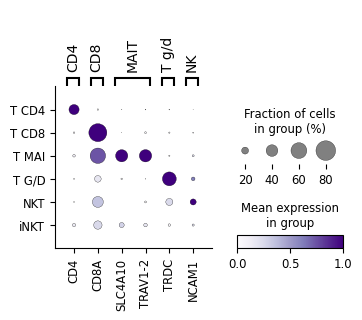

In [22]:
marker_genes ={
        'CD4':['CD4'],
        'CD8':['CD8A'],
        'MAIT':['SLC4A10','TRAV1-2'],
        'T g/d':['TRDC'],
        'NK':['NCAM1'],
}

custom_order=['T CD4','T CD8', 'T MAI', 'T G/D', 'NKT', 'iNKT']

g = sc.pl.dotplot(
    adata,
    groupby='annotation_level_1',
    var_names=marker_genes,
    cmap='Purples',
    categories_order=custom_order,
    return_fig=True,
    standard_scale='var',
    show=False)

#g.savefig(save_dir+'dotplot_level_1.pdf')
g.show()

In [23]:
def check_invariant(row):
    # Check for MAI T cell pattern
    if 'TRAV1-2*' in row['IR_VJ_1_v_call']:
        if any(substr in row['IR_VJ_1_j_call'] for substr in ['TRAJ33', 'TRAJ20', 'TRAJ12']):
            return 'MAIT'
    # Check for iNK T cell pattern
    elif 'TRAV10*' in row['IR_VJ_1_v_call']:
        if 'TRAJ18' in row['IR_VJ_1_j_call']:
            return 'iNKT'
    return 'Conventional'
adata.obs['invariant'] = adata.obs.apply(lambda row: check_invariant(row), axis=1)

In [24]:
adata.obs['TRAV10'] = adata.obs['IR_VJ_1_v_call'].str.contains('TRAV10', na=False)
adata.obs['TRAJ18'] = adata.obs['IR_VJ_1_j_call'].str.contains('TRAJ18', na=False)
adata.obs['TRBV25-1'] = adata.obs['IR_VDJ_1_v_call'].str.contains('TRBV25-1', na=False)

adata.obs['TRAV1-2*01'] = adata.obs['IR_VJ_1_v_call'].str.contains('TRAV1-2*01', na=False)
adata.obs['TRAV1-2*03'] = adata.obs['IR_VJ_1_v_call'].str.contains('TRAV1-2*03', na=False)
adata.obs[' TRAV1-2'] = adata.obs['IR_VJ_1_v_call'].str.contains('TRAV1-2', na=False)

adata.obs['TRAJ33'] = adata.obs['IR_VJ_1_j_call'].str.contains('TRAJ33', na=False)
adata.obs['TRAJ20'] = adata.obs['IR_VJ_1_j_call'].str.contains('TRAJ20', na=False)
adata.obs['TRAJ12'] = adata.obs['IR_VJ_1_j_call'].str.contains('TRAJ12', na=False)

In [25]:
TCR_genes={
    'MAIT':[' TRAV1-2','TRAJ33'],
    'iNKT':['TRAV10','TRAJ18']
}

/rfs/project/rfs-iCNyzSAaucw/lk530/miniconda3/envs/Scanpy/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:2051: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if group not in list(adata.obs_keys()) + [adata.obs.index.name]:


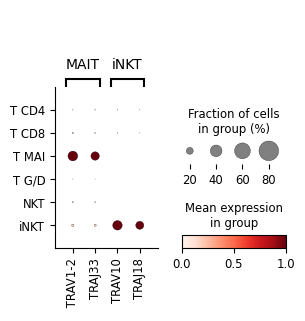

In [26]:
g = sc.pl.dotplot(
    adata,
    groupby='annotation_level_1',
    var_names=TCR_genes,
    cmap='Reds',
    dot_max=0.8,
    categories_order=custom_order,
    return_fig=True,
    standard_scale='var',
    show=False)

#g.savefig(save_dir+'dotplot_MIAT_iNKT_TCRs_max_dot_level_1.pdf')
g.show()